# **Set Up**

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import glob
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
Device: cuda
GPU: Tesla T4


In [3]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

DATASET_ROOT = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026"
TRAIN_AUDIO = f"{DATASET_ROOT}/train_audio"

train_df = pd.read_csv(f"{DATASET_ROOT}/train.csv")

train_df["filepath"] = train_df["filename"].apply(
    lambda x: os.path.join(TRAIN_AUDIO, x)
)

# keep only files that exist
train_df = train_df[train_df["filepath"].apply(os.path.exists)].reset_index(drop=True)

print(train_df.shape)
print("Species:", train_df["primary_label"].nunique())

(608, 16)
Species: 32


# **Dataset**

In [3]:
import os
import glob
import re
import torch
from collections import defaultdict
from torch.utils.data import Dataset

class RecordingMelDataset(Dataset):
    def __init__(self, folder):
        self.folder = folder
        self.files = sorted(glob.glob(folder + "/*.pt"))

        self.recording_to_files = defaultdict(list)

        for path in self.files:
            name = os.path.basename(path)

            # expected: train_123_window0.pt or val_123_window0.pt
            match = re.match(r"(train|val)_(\d+)_window(\d+)\.pt", name)

            if match is None:
                raise ValueError(f"Unexpected filename format: {name}")

            split, rec_id, window_idx = match.groups()

            self.recording_to_files[rec_id].append(
                (int(window_idx), path)
            )

        self.recordings = sorted(self.recording_to_files.keys())

    def __len__(self):
        return len(self.recordings)

    def __getitem__(self, idx):
        rec_id = self.recordings[idx]

        window_paths = sorted(
            self.recording_to_files[rec_id],
            key=lambda x: x[0]
        )

        windows = []
        label = None
        primary_label = None

        for window_idx, path in window_paths:
            item = torch.load(path, map_location="cpu")

            windows.append(item["mel"].float())

            if label is None:
                label = torch.argmax(item["label"]).long()
                primary_label = str(item["primary_label"])

        x = torch.stack(windows)

        return x, label, primary_label

In [13]:
import glob, os

TRAIN_DIR = "/content/drive/MyDrive/birdclef_dataset/mels_top30_train_12windows"
VAL_DIR   = "/content/drive/MyDrive/birdclef_dataset/mels_top30_val_12windows"

print("Train files:", len(glob.glob(TRAIN_DIR + "/*.pt")))
print("Val files:", len(glob.glob(VAL_DIR + "/*.pt")))

print(glob.glob(TRAIN_DIR + "/*.pt")[:3])
print(glob.glob(VAL_DIR + "/*.pt")[:3])

Train files: 57600
Val files: 14400
['/content/drive/MyDrive/birdclef_dataset/mels_top30_train_12windows/train_4716_window8.pt', '/content/drive/MyDrive/birdclef_dataset/mels_top30_train_12windows/train_4716_window9.pt', '/content/drive/MyDrive/birdclef_dataset/mels_top30_train_12windows/train_4716_window10.pt']
['/content/drive/MyDrive/birdclef_dataset/mels_top30_val_12windows/val_1116_window8.pt', '/content/drive/MyDrive/birdclef_dataset/mels_top30_val_12windows/val_1116_window9.pt', '/content/drive/MyDrive/birdclef_dataset/mels_top30_val_12windows/val_1116_window10.pt']


In [ ]:
top_n = 30

birds_df = train_df[train_df["class_name"] == "Aves"].copy()

top_species = (
    birds_df["primary_label"]
    .value_counts()
    .head(top_n)
    .index
)

top30_df = birds_df[
    birds_df["primary_label"].isin(top_species)
].copy()

print(top30_df["primary_label"].nunique())
print(top30_df["primary_label"].value_counts())

In [ ]:
N_PER_SPECIES = 200

balanced_top30_df = (
    top30_df
    .groupby("primary_label", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), N_PER_SPECIES),
        random_state=42
    ))
    .reset_index(drop=True)
)

print(balanced_top30_df["primary_label"].value_counts())
print(balanced_top30_df.shape)

In [ ]:
from sklearn.model_selection import train_test_split

train_top30_df, val_top30_df = train_test_split(
    balanced_top30_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_top30_df["primary_label"]
)

train_top30_df = train_top30_df.reset_index(drop=True)
val_top30_df = val_top30_df.reset_index(drop=True)

print("Train:", train_top30_df.shape)
print("Val:", val_top30_df.shape)

print("\nTrain species counts:")
print(train_top30_df["primary_label"].value_counts().sort_index())

print("\nVal species counts:")
print(val_top30_df["primary_label"].value_counts().sort_index())

# **Create Mel files**

In [43]:
import os
import torch
import torchaudio
from tqdm import tqdm

TRAIN_SAVE_DIR = "/content/drive/MyDrive/birdclef_dataset/mels_top30_train_12windows"
VAL_SAVE_DIR   = "/content/drive/MyDrive/birdclef_dataset/mels_top30_val_12windows"

os.makedirs(TRAIN_SAVE_DIR, exist_ok=True)
os.makedirs(VAL_SAVE_DIR, exist_ok=True)


# label mapping
# label mapping for Top-30 only
labels = sorted(balanced_top30_df["primary_label"].unique())

label_to_id = {
    label: idx
    for idx, label in enumerate(labels)
}

id_to_label = {
    idx: label
    for label, idx in label_to_id.items()
}

num_classes = len(labels)

print("Classes:", num_classes)
print(label_to_id)



print("Classes:", num_classes)


def make_label_vector(primary_label):
    y = torch.zeros(num_classes, dtype=torch.float32)
    y[label_to_id[primary_label]] = 1.0
    return y


def audio_to_mel_windows(
    audio_path,
    sample_rate=32000,
    total_sec=60,
    window_sec=5,
    n_mels=128,
    n_fft=2048,
    hop_length=512
):
    waveform, sr = torchaudio.load(audio_path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sr != sample_rate:
        waveform = torchaudio.transforms.Resample(sr, sample_rate)(waveform)

    total_len = sample_rate * total_sec
    window_len = sample_rate * window_sec

    if waveform.shape[1] < total_len:
        waveform = torch.nn.functional.pad(
            waveform,
            (0, total_len - waveform.shape[1])
        )
    else:
        waveform = waveform[:, :total_len]

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0
    )

    db_transform = torchaudio.transforms.AmplitudeToDB()

    mels = []

    for i in range(total_sec // window_sec):
        start = i * window_len
        end = start + window_len

        window = waveform[:, start:end]

        mel = mel_transform(window)
        mel = db_transform(mel)

        mels.append(mel)

    return mels


def generate_mels_from_df(df, save_dir, prefix):
    for idx, row in tqdm(df.iterrows(), total=len(df), desc=prefix):

        audio_path = row["filepath"]
        primary_label = row["primary_label"]

        label_vector = make_label_vector(primary_label)

        # use row index as recording ID inside this split
        rec_id = idx

        mels = audio_to_mel_windows(audio_path)

        for window_idx, mel in enumerate(mels):

            save_path = os.path.join(
                save_dir,
                f"{prefix}_{rec_id}_window{window_idx}.pt"
            )

            if os.path.exists(save_path):
                continue

            torch.save(
        {
          "mel": mel,
         "label": label_vector,
         "label_id": label_to_id[primary_label],
         "primary_label": str(primary_label),
          "source_file": audio_path,
         "window_idx": window_idx
         },
       save_path
        )

Classes: 30
{'banana': 0, 'barant1': 1, 'bbwduc': 2, 'bncfly': 3, 'bobfly1': 4, 'brnowl': 5, 'coffal1': 6, 'compau': 7, 'fepowl': 8, 'greant1': 9, 'grekis': 10, 'greyel': 11, 'gycwor1': 12, 'houspa': 13, 'limpki': 14, 'oliwoo1': 15, 'osprey': 16, 'roahaw': 17, 'rubthr1': 18, 'saffin': 19, 'sobtyr1': 20, 'socfly1': 21, 'sofspi1': 22, 'soulap1': 23, 'squcuc1': 24, 'strcuc1': 25, 'trokin': 26, 'trsowl': 27, 'whtdov': 28, 'yeofly1': 29}
Classes: 30


In [44]:
generate_mels_from_df(
    train_top30_df,
    TRAIN_SAVE_DIR,
    prefix="train"
)

train: 100%|██████████| 4800/4800 [1:30:15<00:00,  1.13s/it]


In [45]:
generate_mels_from_df(
    val_top30_df,
    VAL_SAVE_DIR,
    prefix="val"
)

val: 100%|██████████| 1200/1200 [22:45<00:00,  1.14s/it]


In [46]:
import glob

train_mels = glob.glob(TRAIN_SAVE_DIR + "/*.pt")
val_mels = glob.glob(VAL_SAVE_DIR + "/*.pt")

print("Train windows:", len(train_mels))
print("Val windows:", len(val_mels))

Train windows: 57600
Val windows: 14400


In [ ]:
train_counts = train_df["primary_label"].value_counts()
val_counts = val_df["primary_label"].value_counts()

print("TRAIN")
print(train_counts.describe())

In [46]:
import torch
import matplotlib.pyplot as plt
import os
import glob

FIG_DIR = "/content/drive/MyDrive/birdclef_dataset/report_figures"
os.makedirs(FIG_DIR, exist_ok=True)

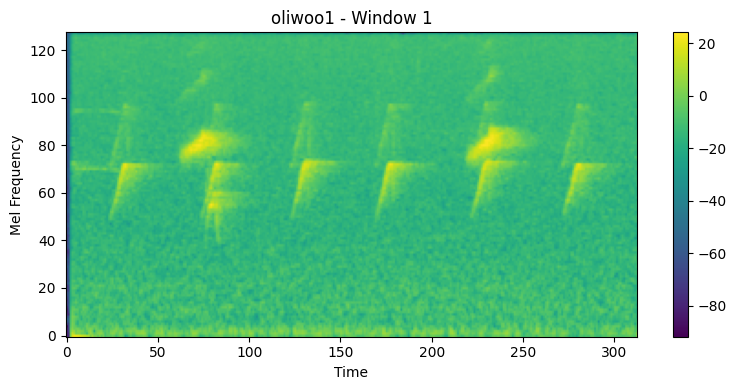

In [49]:
x, y, label = val_dataset[0]

mel = x[0].squeeze().numpy()   # first 5-sec window

plt.figure(figsize=(8,4))
plt.imshow(mel, aspect="auto", origin="lower")
plt.colorbar()
plt.title(f"{label} - Window 1")
plt.xlabel("Time")
plt.ylabel("Mel Frequency")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/recording_mel_single.png", dpi=300)
plt.show()

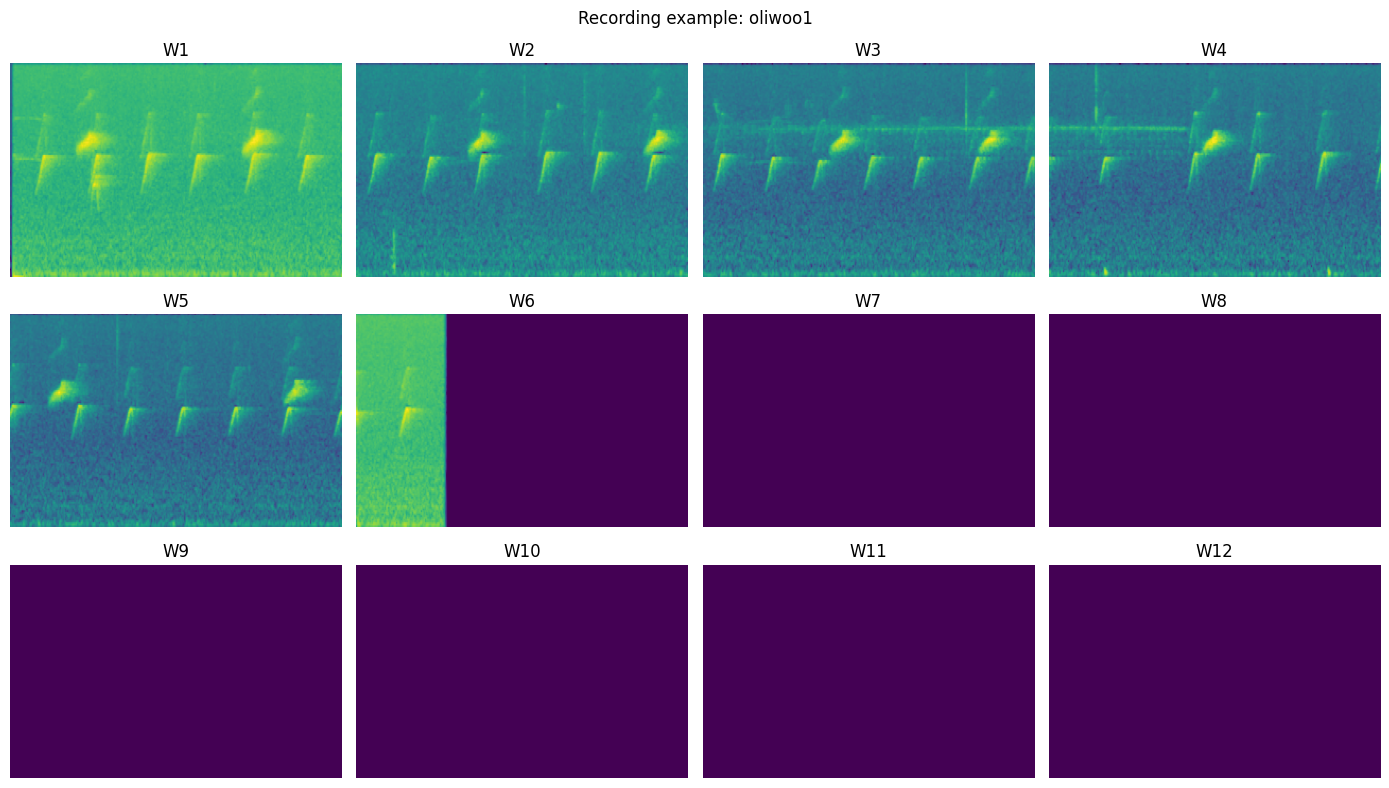

In [50]:
x, y, label = val_dataset[0]

plt.figure(figsize=(14,8))

for i in range(12):
    plt.subplot(3,4,i+1)

    mel = x[i].squeeze().numpy()

    plt.imshow(
        mel,
        aspect="auto",
        origin="lower"
    )

    plt.title(f"W{i+1}")
    plt.axis("off")

plt.suptitle(f"Recording example: {label}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/recording_12_window_grid.png", dpi=300)
plt.show()

In [53]:
import soundfile as sf
import numpy as np

durations = []

for fp in train_top30_df["filepath"].head(500):

    info = sf.info(fp)

    durations.append(
        info.frames / info.samplerate
    )

print("Min:", np.min(durations))
print("Mean:", np.mean(durations))
print("Max:", np.max(durations))

Min: 0.1045
Mean: 38.83914281249999
Max: 1147.951


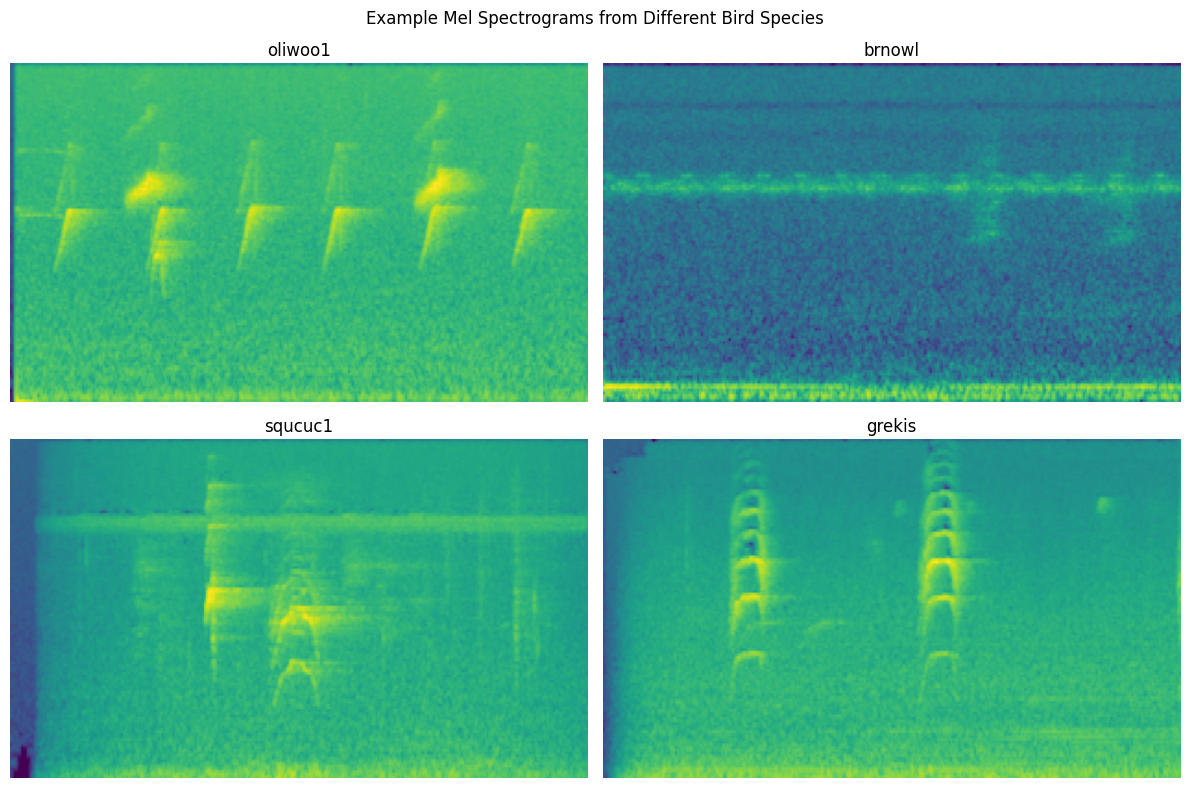

In [51]:
species_seen = set()

plt.figure(figsize=(12,8))

plot_idx = 1

for i in range(len(val_dataset)):

    x, y, label = val_dataset[i]

    if label in species_seen:
        continue

    species_seen.add(label)

    plt.subplot(2,2,plot_idx)

    plt.imshow(
        x[0].squeeze().numpy(),
        aspect="auto",
        origin="lower"
    )

    plt.title(label)
    plt.axis("off")

    plot_idx += 1

    if plot_idx > 4:
        break

plt.suptitle("Example Mel Spectrograms from Different Bird Species")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/species_mel_examples.png", dpi=300)
plt.show()

# **Train / validation split**

In [5]:
TRAIN_DIR = "/content/drive/MyDrive/birdclef_dataset/mels_top30_train_12windows"
VAL_DIR   = "/content/drive/MyDrive/birdclef_dataset/mels_top30_val_12windows"

train_dataset = RecordingMelDataset(TRAIN_DIR)
val_dataset   = RecordingMelDataset(VAL_DIR)

print("Train recordings:", len(train_dataset))
print("Val recordings:", len(val_dataset))

x, y, label = train_dataset[0]

print(x.shape)
print(y)
print(label)

Train recordings: 4800
Val recordings: 1200
torch.Size([12, 1, 128, 313])
tensor(11)
greyel


In [6]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(len(train_loader))
print(len(val_loader))

300
75


# **Plain CNN**

In [17]:
import torch.nn as nn

class CNNEncoder(nn.Module):
    def __init__(self, embedding_dim=512):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2,2)),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4,4))
        )

        self.projection = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256 * 4 * 4, embedding_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = self.features(x)
        x = self.projection(x)
        return x

In [16]:
class RecordingCNN(nn.Module):
    def __init__(self, num_classes, embedding_dim=512):
        super().__init__()

        self.encoder = CNNEncoder(embedding_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(embedding_dim, num_classes)
        )

    def forward(self, x):
        # x: [B, 12, 1, 128, 313]

        b, w, c, h, t = x.shape

        x = x.view(b * w, c, h, t)

        embeddings = self.encoder(x)  # [B*12, 512]

        embeddings = embeddings.view(b, w, -1)

        recording_embedding = embeddings.mean(dim=1)

        logits = self.classifier(recording_embedding)

        return logits

In [21]:
class RecordingCNNMax(nn.Module):
    def __init__(self, num_classes, embedding_dim=512):
        super().__init__()

        self.encoder = CNNEncoder(embedding_dim)

        self.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(embedding_dim, num_classes)
        )

    def forward(self, x):
        # x: [B, 12, 1, 128, 313]

        b, w, c, h, t = x.shape

        x = x.view(b * w, c, h, t)

        embeddings = self.encoder(x)  # [B*12, 512]

        embeddings = embeddings.view(b, w, -1)

        # MAX pooling across the 12 windows
        recording_embedding, _ = torch.max(
            embeddings,
            dim=1
        )

        logits = self.classifier(
            recording_embedding
        )

        return logits

# **CNN + BiLSTM**

In [18]:
class RecordingCNNBiLSTM(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, hidden_dim=256):
        super().__init__()

        self.encoder = CNNEncoder(embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        # x: [B, 12, 1, 128, 313]

        b, w, c, h, t = x.shape

        x = x.view(b * w, c, h, t)

        embeddings = self.encoder(x)  # [B*12, 512]

        embeddings = embeddings.view(b, w, -1)  # [B,12,512]

        lstm_out, _ = self.lstm(embeddings)

        recording_embedding = lstm_out.mean(dim=1)

        logits = self.classifier(recording_embedding)

        return logits

In [19]:
class RecordingCNNBiLSTMMax(nn.Module):
    def __init__(self, num_classes, embedding_dim=512, hidden_dim=256):
        super().__init__()

        self.encoder = CNNEncoder(embedding_dim)

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(hidden_dim * 2, num_classes)
        )

    def forward(self, x):
        # x: [B, 12, 1, 128, 313]

        b, w, c, h, t = x.shape

        x = x.view(b * w, c, h, t)

        embeddings = self.encoder(x)  # [B*12, 512]

        embeddings = embeddings.view(b, w, -1)  # [B,12,512]

        lstm_out, _ = self.lstm(embeddings)

        # MAX pooling across the 12 sequence outputs
        recording_embedding, _ = torch.max(
            lstm_out,
            dim=1
        )

        logits = self.classifier(
            recording_embedding
        )

        return logits

# **Training + validation functions**

In [10]:
criterion = nn.CrossEntropyLoss()


def train_one_epoch(model, loader, optimizer):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for batch_idx, batch in enumerate(loader):
        x = batch[0].to(device)
        y = batch[1].to(device)

        optimizer.zero_grad()

        logits = model(x)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

        if (batch_idx + 1) % 50 == 0:
            print(
                f"Batch {batch_idx+1}/{len(loader)} | "
                f"Loss: {total_loss/(batch_idx+1):.4f} | "
                f"Acc: {correct/total:.4f}"
            )

    return total_loss / len(loader), correct / total


def validate(model, loader):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            y = batch[1].to(device)

            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item()

            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

# **Training wrapper with early stopping**

In [11]:
def train_model(
    model,
    model_name,
    train_loader,
    val_loader,
    epochs=20,
    lr=1e-4,
    weight_decay=1e-4,
    patience=4
):
    model = model.to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")
    best_val_acc = 0.0
    patience_counter = 0

    history = []

    save_path = f"/content/drive/MyDrive/birdclef_dataset/{model_name}_best.pt"

    for epoch in range(1, epochs + 1):
        print(f"\nEpoch {epoch}/{epochs} — {model_name}")

        train_loss, train_acc = train_one_epoch(
            model,
            train_loader,
            optimizer
        )

        val_loss, val_acc = validate(
            model,
            val_loader
        )

        history.append({
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc
        })

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            patience_counter = 0

            torch.save(model.state_dict(), save_path)
            print("Saved new best model.")

        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    history_df = pd.DataFrame(history)

    history_path = f"/content/drive/MyDrive/birdclef_dataset/{model_name}_history.csv"
    history_df.to_csv(history_path, index=False)

    print("\nBest Val Loss:", best_val_loss)
    print("Best Val Acc:", best_val_acc)
    print("Model saved to:", save_path)
    print("History saved to:", history_path)

    return model, history_df

# **Train Models**

In [58]:
recording_cnn = RecordingCNN(num_classes=30)

recording_cnn, recording_cnn_history = train_model(
    model=recording_cnn,
    model_name="top30_recording_cnn",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    lr=1e-4,
    weight_decay=1e-4,
    patience=4
)


Epoch 1/20 — top30_recording_cnn
Batch 50/300 | Loss: 3.4261 | Acc: 0.0425
Batch 100/300 | Loss: 3.4093 | Acc: 0.0456
Batch 150/300 | Loss: 3.4016 | Acc: 0.0462
Batch 200/300 | Loss: 3.3914 | Acc: 0.0475
Batch 250/300 | Loss: 3.3804 | Acc: 0.0525
Batch 300/300 | Loss: 3.3617 | Acc: 0.0592
Train Loss: 3.3617 | Train Acc: 0.0592
Val Loss:   3.2296 | Val Acc:   0.1158
Saved new best model.

Epoch 2/20 — top30_recording_cnn
Batch 50/300 | Loss: 3.2413 | Acc: 0.1013
Batch 100/300 | Loss: 3.2122 | Acc: 0.1025
Batch 150/300 | Loss: 3.1905 | Acc: 0.1067
Batch 200/300 | Loss: 3.1645 | Acc: 0.1166
Batch 250/300 | Loss: 3.1351 | Acc: 0.1237
Batch 300/300 | Loss: 3.1217 | Acc: 0.1244
Train Loss: 3.1217 | Train Acc: 0.1244
Val Loss:   2.9555 | Val Acc:   0.1617
Saved new best model.

Epoch 3/20 — top30_recording_cnn
Batch 50/300 | Loss: 2.9366 | Acc: 0.1650
Batch 100/300 | Loss: 2.9711 | Acc: 0.1481
Batch 150/300 | Loss: 2.9394 | Acc: 0.1558
Batch 200/300 | Loss: 2.9148 | Acc: 0.1622
Batch 250/300

In [23]:
recording_bilstm = RecordingCNNBiLSTM(num_classes=30)

recording_bilstm, recording_bilstm_history = train_model(
    model=recording_bilstm,
    model_name="top30_recording_cnn_bilstm",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    lr=5e-5,
    weight_decay=1e-4,
    patience=4
)


Epoch 1/20 — top30_recording_cnn_bilstm
Batch 50/300 | Loss: 3.4058 | Acc: 0.0275
Batch 100/300 | Loss: 3.4003 | Acc: 0.0362
Batch 150/300 | Loss: 3.4004 | Acc: 0.0350
Batch 200/300 | Loss: 3.3993 | Acc: 0.0359
Batch 250/300 | Loss: 3.3965 | Acc: 0.0352
Batch 300/300 | Loss: 3.3927 | Acc: 0.0402
Train Loss: 3.3927 | Train Acc: 0.0402
Val Loss:   3.3640 | Val Acc:   0.0642
Saved new best model.

Epoch 2/20 — top30_recording_cnn_bilstm
Batch 50/300 | Loss: 3.3579 | Acc: 0.0625
Batch 100/300 | Loss: 3.3459 | Acc: 0.0750
Batch 150/300 | Loss: 3.3372 | Acc: 0.0721
Batch 200/300 | Loss: 3.3154 | Acc: 0.0800
Batch 250/300 | Loss: 3.2905 | Acc: 0.0803
Batch 300/300 | Loss: 3.2572 | Acc: 0.0887
Train Loss: 3.2572 | Train Acc: 0.0887
Val Loss:   3.0175 | Val Acc:   0.1308
Saved new best model.

Epoch 3/20 — top30_recording_cnn_bilstm
Batch 50/300 | Loss: 3.0265 | Acc: 0.1138
Batch 100/300 | Loss: 3.0045 | Acc: 0.1256
Batch 150/300 | Loss: 2.9872 | Acc: 0.1300
Batch 200/300 | Loss: 2.9507 | Acc:

In [25]:
recording_cnn_max = RecordingCNNMax(
    num_classes=30
)

recording_cnn_max, recording_cnn_max_history = train_model(
    model=recording_cnn_max,
    model_name="top30_recording_cnn_maxpool",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    lr=1e-4,
    weight_decay=1e-4,
    patience=4
)


Epoch 1/20 — top30_recording_cnn_maxpool
Batch 50/300 | Loss: 3.4748 | Acc: 0.0450
Batch 100/300 | Loss: 3.4436 | Acc: 0.0563
Batch 150/300 | Loss: 3.4218 | Acc: 0.0587
Batch 200/300 | Loss: 3.4010 | Acc: 0.0622
Batch 250/300 | Loss: 3.3682 | Acc: 0.0675
Batch 300/300 | Loss: 3.3339 | Acc: 0.0767
Train Loss: 3.3339 | Train Acc: 0.0767
Val Loss:   3.2015 | Val Acc:   0.1042
Saved new best model.

Epoch 2/20 — top30_recording_cnn_maxpool
Batch 50/300 | Loss: 3.1020 | Acc: 0.1075
Batch 100/300 | Loss: 3.0844 | Acc: 0.1175
Batch 150/300 | Loss: 3.0559 | Acc: 0.1304
Batch 200/300 | Loss: 3.0385 | Acc: 0.1356
Batch 250/300 | Loss: 3.0168 | Acc: 0.1383
Batch 300/300 | Loss: 2.9952 | Acc: 0.1456
Train Loss: 2.9952 | Train Acc: 0.1456
Val Loss:   2.7524 | Val Acc:   0.2275
Saved new best model.

Epoch 3/20 — top30_recording_cnn_maxpool
Batch 50/300 | Loss: 2.8072 | Acc: 0.1787
Batch 100/300 | Loss: 2.7848 | Acc: 0.1975
Batch 150/300 | Loss: 2.7594 | Acc: 0.2008
Batch 200/300 | Loss: 2.7575 | A

In [12]:
recording_bilstm_max = RecordingCNNBiLSTMMax(
    num_classes=30
)

recording_bilstm_max, recording_bilstm_max_history = train_model(
    model=recording_bilstm_max,
    model_name="top30_recording_cnn_bilstm_maxpool",
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=20,
    lr=5e-5,
    weight_decay=1e-4,
    patience=4
)


Epoch 1/20 — top30_recording_cnn_bilstm_maxpool
Batch 50/300 | Loss: 3.4042 | Acc: 0.0387
Batch 100/300 | Loss: 3.4011 | Acc: 0.0444
Batch 150/300 | Loss: 3.4003 | Acc: 0.0400
Batch 200/300 | Loss: 3.3974 | Acc: 0.0409
Batch 250/300 | Loss: 3.3960 | Acc: 0.0425
Batch 300/300 | Loss: 3.3926 | Acc: 0.0471
Train Loss: 3.3926 | Train Acc: 0.0471
Val Loss:   3.3634 | Val Acc:   0.0808
Saved new best model.

Epoch 2/20 — top30_recording_cnn_bilstm_maxpool
Batch 50/300 | Loss: 3.3641 | Acc: 0.0525
Batch 100/300 | Loss: 3.3522 | Acc: 0.0694
Batch 150/300 | Loss: 3.3357 | Acc: 0.0788
Batch 200/300 | Loss: 3.3233 | Acc: 0.0825
Batch 250/300 | Loss: 3.3124 | Acc: 0.0882
Batch 300/300 | Loss: 3.2946 | Acc: 0.0917
Train Loss: 3.2946 | Train Acc: 0.0917
Val Loss:   3.1830 | Val Acc:   0.1050
Saved new best model.

Epoch 3/20 — top30_recording_cnn_bilstm_maxpool
Batch 50/300 | Loss: 3.1391 | Acc: 0.1300
Batch 100/300 | Loss: 3.1315 | Acc: 0.1294
Batch 150/300 | Loss: 3.1055 | Acc: 0.1304
Batch 200/3

# **Collect predictions**

In [8]:
def get_predictions(model, loader):

    all_true = []
    all_preds = []
    all_probs = []

    model.eval()

    with torch.no_grad():

        for batch in loader:
            x = batch[0]
            y = batch[1]

            x = x.to(device)

            logits = model(x)

            probs = torch.softmax(
                logits,
                dim=1
            )

            preds = probs.argmax(dim=1)

            all_true.extend(
                y.numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    return (
        np.array(all_true),
        np.array(all_preds),
        np.array(all_probs)
    )

# **Final Evaluation Metrics**

In [13]:
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [22]:
models_to_eval = {
    "CNN_Mean":
        ("top30_recording_cnn_best.pt",
         RecordingCNN(num_classes=30)),

    "CNNBiLSTM_Mean":
        ("top30_recording_cnn_bilstm_best.pt",
         RecordingCNNBiLSTM(num_classes=30)),

    "CNN_Max":
        ("top30_recording_cnn_maxpool_best.pt",
         RecordingCNNMax(num_classes=30)),

    "CNNBiLSTM_Max":
        ("top30_recording_cnn_bilstm_maxpool_best.pt",
         RecordingCNNBiLSTMMax(num_classes=30))
}

In [23]:
def evaluate_model(model, loader):

    model.eval()

    all_true = []
    all_preds = []
    all_probs = []

    with torch.no_grad():

        for batch in loader:

            x = batch[0].to(device)
            y = batch[1].to(device)

            logits = model(x)

            probs = torch.softmax(
                logits,
                dim=1
            )

            preds = torch.argmax(
                probs,
                dim=1
            )

            all_true.extend(
                y.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    all_true = np.array(all_true)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    acc = accuracy_score(
        all_true,
        all_preds
    )

    macro_f1 = f1_score(
        all_true,
        all_preds,
        average="macro"
    )

    weighted_f1 = f1_score(
        all_true,
        all_preds,
        average="weighted"
    )

    auc = roc_auc_score(
        all_true,
        all_probs,
        multi_class="ovr",
        average="macro"
    )

    return {
        "Accuracy": acc,
        "Macro_F1": macro_f1,
        "Weighted_F1": weighted_f1,
        "Macro_AUC": auc
    }

In [24]:
results = []

for model_name, (file_name, model) in models_to_eval.items():

    model.load_state_dict(
        torch.load(
            f"/content/drive/MyDrive/birdclef_dataset/{file_name}",
            map_location=device
        )
    )

    model = model.to(device)

    metrics = evaluate_model(
        model,
        val_loader
    )

    metrics["Model"] = model_name

    results.append(metrics)

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Macro_F1",
        "Weighted_F1",
        "Macro_AUC"
    ]
]

results_df.sort_values(
    "Accuracy",
    ascending=False
)

,Model,Accuracy,Macro_F1,Weighted_F1,Macro_AUC
2,CNN_Max,0.643333,0.643699,0.643699,0.958366
0,CNN_Mean,0.532500,0.531648,0.531648,0.924764
1,CNNBiLSTM_Mean,0.517500,0.512645,0.512645,0.936155
3,CNNBiLSTM_Max,0.487500,0.476928,0.476928,0.920566


In [38]:
from sklearn.metrics import top_k_accuracy_score
import numpy as np
import torch

def evaluate_topk(model, loader, k_values=[1,3,5]):

    model.eval()

    all_true = []
    all_probs = []

    with torch.no_grad():
        for batch in loader:

            x = batch[0].to(device)
            y = batch[1].to(device)

            logits = model(x)

            probs = torch.softmax(
                logits,
                dim=1
            )

            all_true.extend(
                y.cpu().numpy()
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

    all_true = np.array(all_true)
    all_probs = np.array(all_probs)

    results = {}

    for k in k_values:
        results[f"Top-{k}"] = top_k_accuracy_score(
            all_true,
            all_probs,
            k=k,
            labels=np.arange(all_probs.shape[1])
        )

    return results

In [40]:
recording_cnn = RecordingCNN(num_classes=30)
recording_cnn.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/birdclef_dataset/top30_recording_cnn_best.pt",
        map_location=device
    )
)

recording_bilstm = RecordingCNNBiLSTM(num_classes=30)
recording_bilstm.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/birdclef_dataset/top30_recording_cnn_bilstm_best.pt",
        map_location=device
    )
)

recording_cnn_max = RecordingCNNMax(num_classes=30)
recording_cnn_max.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/birdclef_dataset/top30_recording_cnn_maxpool_best.pt",
        map_location=device
    )
)

recording_bilstm_max = RecordingCNNBiLSTMMax(num_classes=30)
recording_bilstm_max.load_state_dict(
    torch.load(
        "/content/drive/MyDrive/birdclef_dataset/top30_recording_cnn_bilstm_maxpool_best.pt",
        map_location=device
    )
)

<All keys matched successfully>

In [44]:
models = {
    "CNN_Mean": recording_cnn.to(device),
    "CNNBiLSTM_Mean": recording_bilstm.to(device),
    "CNN_Max": recording_cnn_max.to(device),
    "CNNBiLSTM_Max": recording_bilstm_max.to(device)
}

for name, model in models.items():

    scores = evaluate_topk(
        model,
        val_loader,
        k_values=[1,3,5]
    )

    print("\n", name)
    print(scores)


 CNN_Mean
{'Top-1': np.float64(0.5325), 'Top-3': np.float64(0.7466666666666667), 'Top-5': np.float64(0.83)}

 CNNBiLSTM_Mean
{'Top-1': np.float64(0.5175), 'Top-3': np.float64(0.7541666666666667), 'Top-5': np.float64(0.8366666666666667)}

 CNN_Max
{'Top-1': np.float64(0.6433333333333333), 'Top-3': np.float64(0.8066666666666666), 'Top-5': np.float64(0.8658333333333333)}

 CNNBiLSTM_Max
{'Top-1': np.float64(0.4875), 'Top-3': np.float64(0.7141666666666666), 'Top-5': np.float64(0.7991666666666667)}


# **Pretrained model bench -- Perch**

In [27]:
import numpy as np
from tqdm import tqdm

def extract_perch_embeddings(df, save_prefix):
    X = []
    y = []
    files = []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        emb = perch_embedding_for_recording(row["filepath"])

        X.append(emb)
        y.append(str(row["primary_label"]))
        files.append(row["filepath"])

    X = np.array(X)
    y = np.array(y)
    files = np.array(files)

    BASE = "/content/drive/MyDrive/birdclef_dataset"

    np.save(f"{BASE}/{save_prefix}_X.npy", X)
    np.save(f"{BASE}/{save_prefix}_y.npy", y)
    np.save(f"{BASE}/{save_prefix}_files.npy", files)

    print(save_prefix, X.shape, y.shape)

    return X, y, files

In [31]:
import os
import pandas as pd

DATASET_ROOT = "/content/drive/MyDrive/birdclef_dataset/birdclef-2026"
TRAIN_AUDIO = f"{DATASET_ROOT}/train_audio"

train_df = pd.read_csv(f"{DATASET_ROOT}/train.csv")

train_df["filepath"] = train_df["filename"].apply(
    lambda x: os.path.join(TRAIN_AUDIO, x)
)

print(train_df.shape)

(35549, 16)


In [32]:
!pip install -q tensorflow_hub

import tensorflow as tf
import tensorflow_hub as hub

MODEL_HANDLE = "https://kaggle.com/models/google/bird-vocalization-classifier/frameworks/TensorFlow2/variations/bird-vocalization-classifier/versions/1"

perch_model = hub.load(MODEL_HANDLE)

print("Perch loaded")

Perch loaded


In [33]:
from sklearn.model_selection import train_test_split

birds_df = train_df[train_df["class_name"] == "Aves"].copy()

top30_species = (
    birds_df["primary_label"]
    .value_counts()
    .head(30)
    .index
)

top30_df = birds_df[
    birds_df["primary_label"].isin(top30_species)
].copy()

top30_balanced = (
    top30_df
    .groupby("primary_label", group_keys=False)
    .sample(n=200, random_state=42)
    .reset_index(drop=True)
)

train_top30_df, val_top30_df = train_test_split(
    top30_balanced,
    test_size=0.2,
    random_state=42,
    stratify=top30_balanced["primary_label"]
)

train_top30_df = train_top30_df.reset_index(drop=True)
val_top30_df = val_top30_df.reset_index(drop=True)

print(train_top30_df.shape)
print(val_top30_df.shape)
print(val_top30_df["primary_label"].value_counts().head())

(4800, 16)
(1200, 16)
primary_label
oliwoo1    40
brnowl     40
compau     40
barant1    40
limpki     40
Name: count, dtype: int64


In [34]:
import torch
import torchaudio
import tensorflow as tf
import numpy as np
from tqdm import tqdm

def perch_embedding_for_recording(audio_path, sample_rate=32000):
    waveform, sr = torchaudio.load(audio_path)

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0)
    else:
        waveform = waveform.squeeze(0)

    if sr != sample_rate:
        waveform = torchaudio.transforms.Resample(sr, sample_rate)(waveform)

    total_len = sample_rate * 60
    window_len = sample_rate * 5

    if waveform.shape[0] < total_len:
        waveform = torch.nn.functional.pad(
            waveform,
            (0, total_len - waveform.shape[0])
        )
    else:
        waveform = waveform[:total_len]

    embeddings = []

    for i in range(12):
        window = waveform[i * window_len:(i + 1) * window_len]
        window = window.numpy().astype(np.float32)[None, :]

        outputs = perch_model.signatures["serving_default"](
            inputs=tf.constant(window)
        )

        embeddings.append(outputs["output_1"].numpy()[0])

    return np.mean(embeddings, axis=0)


def extract_perch_embeddings(df, save_prefix):
    X, y, files = [], [], []

    for _, row in tqdm(df.iterrows(), total=len(df)):
        emb = perch_embedding_for_recording(row["filepath"])
        X.append(emb)
        y.append(str(row["primary_label"]))
        files.append(row["filepath"])

    X = np.array(X)
    y = np.array(y)
    files = np.array(files)

    BASE = "/content/drive/MyDrive/birdclef_dataset"

    np.save(f"{BASE}/{save_prefix}_X.npy", X)
    np.save(f"{BASE}/{save_prefix}_y.npy", y)
    np.save(f"{BASE}/{save_prefix}_files.npy", files)

    print(save_prefix, X.shape, y.shape)

    return X, y, files

In [35]:
X_val_perch, y_val_perch, files_val_perch = extract_perch_embeddings(
    val_top30_df,
    "perch_top30_val"
)

100%|██████████| 1200/1200 [12:50<00:00,  1.56it/s]

perch_top30_val (1200, 1280) (1200,)


In [36]:
X_train_perch, y_train_perch, files_train_perch = extract_perch_embeddings(
    train_top30_df,
    "perch_top30_train"
)

100%|██████████| 4800/4800 [48:52<00:00,  1.64it/s]

perch_top30_train (4800, 1280) (4800,)


In [37]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

le = LabelEncoder()

y_train_id = le.fit_transform(y_train_perch)
y_val_id = le.transform(y_val_perch)

clf = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver="lbfgs",
    n_jobs=-1
)

clf.fit(X_train_perch, y_train_id)

perch_probs = clf.predict_proba(X_val_perch)
perch_preds = perch_probs.argmax(axis=1)

print("Perch+LR Accuracy:", accuracy_score(y_val_id, perch_preds))
print("Perch+LR Macro F1:", f1_score(y_val_id, perch_preds, average="macro"))
print("Perch+LR Weighted F1:", f1_score(y_val_id, perch_preds, average="weighted"))
print("Perch+LR Macro AUC:", roc_auc_score(
    y_val_id,
    perch_probs,
    multi_class="ovr",
    average="macro"
))

Perch+LR Accuracy: 0.8958333333333334
Perch+LR Macro F1: 0.8968833384144815
Perch+LR Weighted F1: 0.8968833384144816
Perch+LR Macro AUC: 0.9917701149425288
